# 🤖 2. Selective Preprocessing - Regression model with NO Dropouts
**Deep learning model for blue fundus eye pictures regression**

The purpose of this notebook is to evaluate a regression CNN model across different selective preprocessing scenarios.

The regression target is:

- `target_SE`: spherical equivalent value in diopters.

The same lightweight CNN architecture is trained on four preprocessing scenarios:The final purpose of this notebook is to apply last notebook's regession deep learning model (small_cnn_regrss) to different levels of preprocessing on the fundus images, so as to set a baseline for the project depending on the level of preprocessing. There will be 4 scenarios performed:

A. Normalization only
- With RGB conversion and normalization to [0–1].
- No geometry: no circle detection, nor padding/resizing (only dataloader resizer for 224×224 pixels).
- No CLAHE.
- No Augmentations.

B. Geometry + Normalization
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- No Augmentations.

C. Geometry + Normalization + Illumination (no Augmentantions)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- With CLAHE (luminance or blue can be chosen).
- No Augmentations.

D. Geometry + Normalization + Augmentations (no illumination)
- With RGB conversion and normalization to [0–1].
- With geometry: fundus circle detection + circular crop + padding to square + resizing to 224×224.
- No CLAHE.
- With geometric Augmentations: flip, light rotation and zoom applied at dataloader.

## ⚙️ 1. Setting up



In [1]:
from pathlib import Path #useful since it makes path use easier (can append paths and more)
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from sklearn.model_selection import train_test_split - not necessary, we import splits now
# from sklearn.utils.class_weight import compute_class_weight - en regrss no se usan
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    validate_main_structure,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

IMAGES_DIR = paths["images"]
TABLES_DIR = paths["tables"]
SPLITS_DIR = paths["splits"]
MODELS_DIR = paths["models"]

for folder in [IMAGES_DIR, TABLES_DIR, SPLITS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Images dir:", IMAGES_DIR)
print("Tables dir:", TABLES_DIR)
print("Splits dir:", SPLITS_DIR)
print("Models dir:", MODELS_DIR)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Images dir: C:\Users\paula\0B_TFGBiomed_Exe\Images
Tables dir: C:\Users\paula\0B_TFGBiomed_Exe\Tables
Splits dir: C:\Users\paula\0B_TFGBiomed_Exe\Splits
Models dir: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Selective preprocessing output folders ===========================================================

SPLIT_ROOT = SPLITS_DIR / "Regression" / "SelectivePreproc"
MODELS_DIR_SELECTIVE = MODELS_DIR / "WithoutDropout" / "SelectivePreproc" / "Regression"

SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR_SELECTIVE.mkdir(parents=True, exist_ok=True)

print("Split root:", SPLIT_ROOT)
print("Models selective output:", MODELS_DIR_SELECTIVE)

Split root: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\SelectivePreproc
Models selective output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\SelectivePreproc\Regression


In [3]:
# Paths to selectively preprocessed sets of images
SCENARIO_TABLES = {
    "A_Raw_minimal": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.A.xlsx",         # Raw with minimal preproc
    "B_GeoNorm": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx",             # geometry + normalization
    "C_GeoNorm_Illum_NoAug": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.C.xlsx", # geometry + normalization + illumination 
    "D_GeoNorm_Aug_NoIllum": TABLES_DIR / "MatchTables" / "TablaMatch_SCENARIO.B.xlsx" # geometry + normalization + augmentations - there is no such path, will be using B for D
}

EXPERIMENTS = [ # (name, data_root, augment_in_loader, normalization)
    {
        "name": "A_Raw_minimal",
        "table": SCENARIO_TABLES["A_Raw_minimal"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "B_GeoNorm",
        "table": SCENARIO_TABLES["B_GeoNorm"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "C_GeoNorm_Illum_NoAug",
        "table": SCENARIO_TABLES["C_GeoNorm_Illum_NoAug"],
        "do_aug": False,
        "normalization": "0-1"
    },
    {
        "name": "D_GeoNorm_Aug_NoIllum",
        "table": SCENARIO_TABLES["D_GeoNorm_Aug_NoIllum"],  #makes use of geom+norm to make augmentations without illumination
        "do_aug": True,
        "normalization": "0-1"
    }
]

for name, path in SCENARIO_TABLES.items():
    print(name, "exists:", path.exists(), "|", path)
    assert path.exists(), f"Missing scenario table: {path}"

A_Raw_minimal exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.A.xlsx
B_GeoNorm exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx
C_GeoNorm_Illum_NoAug exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.C.xlsx
D_GeoNorm_Aug_NoIllum exists: True | C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\TablaMatch_SCENARIO.B.xlsx


## 🛠️  2. Helpers preparation

To keep the codebase clean and efficient, several helper functions were implemented.  
These functions encapsulate small, reusable tasks that will be required multiple times throughout the preprocessing pipeline.

####  2.1 Loading base table

In [4]:
base_df = pd.read_excel(SCENARIO_TABLES["A_Raw_minimal"])

# Keep only rows with valid paths and regression targets
base_df = base_df[base_df["image_path"].notna()].copy()
base_df = base_df[base_df["filename"].notna()].copy()
base_df = base_df[base_df["target_SE"].notna()].copy()

base_df["image_path"] = base_df["image_path"].astype(str)
base_df["filename"] = base_df["filename"].astype(str)
base_df["patient_id"] = base_df["patient_id"].astype(str).str.upper().str.strip()
base_df["target_SE"] = pd.to_numeric(base_df["target_SE"], errors="coerce")

base_df = base_df.dropna(
    subset=["image_path", "filename", "patient_id", "target_SE"]
).copy()

print("Total valid images for regression:", len(base_df))

print("\nTarget SE summary:")
print(base_df["target_SE"].describe())

base_df.head()

Total valid images for regression: 2126

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,detect_fundus,pad_and_resize,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
1,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
2,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
3,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none
4,C:\Users\paula\0B_TFGBiomed\Images\02_Selectiv...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A_Raw_minimal,224,False,False,False,none


The regression dataset contains **2,126 valid retinal images** with available **SE** values. The SE distribution is highly centred around **0 D**, with a mean close to **0.02 D**, a median of **0 D**, and a standard deviation of approximately **2.11 D**.

This distribution is important because it makes direct SE regression difficult to interpret. Since many samples are close to 0 D, a model can obtain a moderate MAE by predicting values near the centre of the distribution, even if it is not truly learning image-based refractive information.

This is the same dataset used in the selective regression notebook with Dropout, so this notebook mainly evaluates the effect of removing Dropout while keeping the selective preprocessing scenarios unchanged.


#### ✂️  2.2 Splitting the dataset
Stratified (avoids bias since myope class is slightly bigger than the normal one) 80/10/10 split by chosen root dataset.

In [5]:
# Load existing patient-level regression splits created in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb

def load_existing_scenario_split(scenario_name: str) -> dict:
    scenario_split_dir = SPLIT_ROOT / scenario_name

    train_csv = scenario_split_dir / "train.csv"
    val_csv   = scenario_split_dir / "val.csv"
    test_csv  = scenario_split_dir / "test.csv"

    for csv_path in [train_csv, val_csv, test_csv]:
        if not csv_path.exists():
            raise FileNotFoundError(
                f"Missing split file: {csv_path}. "
                "Run 00_CreatePatientLevelSplits_Classf_Regrss.ipynb first."
            )

    return {
        "train": train_csv,
        "val": val_csv,
        "test": test_csv,
    }


def check_no_overlap(train_df, val_df, test_df, column: str, name: str) -> None:
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


SCENARIO_SPLITS = {}

for exp in EXPERIMENTS:
    name = exp["name"]
    SCENARIO_SPLITS[name] = load_existing_scenario_split(name)

    train_df = pd.read_csv(SCENARIO_SPLITS[name]["train"])
    val_df   = pd.read_csv(SCENARIO_SPLITS[name]["val"])
    test_df  = pd.read_csv(SCENARIO_SPLITS[name]["test"])

    print(f"\n===== {name} =====")
    print("Train:", len(train_df))
    print("Val:  ", len(val_df))
    print("Test: ", len(test_df))

    check_no_overlap(train_df, val_df, test_df, "patient_id", f"{name} patient")
    check_no_overlap(train_df, val_df, test_df, "image_path", f"{name} image")

    print("\nTrain target SE summary:")
    print(train_df["target_SE"].describe())

    print("\nVal target SE summary:")
    print(val_df["target_SE"].describe())

    print("\nTest target SE summary:")
    print(test_df["target_SE"].describe())


===== A_Raw_minimal =====
Train: 1700
Val:   209
Test:  217
OK: no A_Raw_minimal patient overlap across train/val/test.
OK: no A_Raw_minimal image overlap across train/val/test.

Train target SE summary:
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64

Val target SE summary:
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750000
max        5.000000
Name: target_SE, dtype: float64

Test target SE summary:
count    217.000000
mean       0.097926
std        1.806159
min       -6.500000
25%       -0.250000
50%        0.000000
75%        0.750000
max        9.000000
Name: target_SE, dtype: float64

===== B_GeoNorm =====
Train: 1700
Val:   209
Test:  217
OK: no B_GeoNorm patient overlap across train/val/test.
OK: no B_GeoNorm image overlap across train/val/t

Split interpretation

The same patient-level train/validation/test split is reused for all four preprocessing scenarios: **1,700 training images**, **209 validation images** and **217 test images**.

The output confirms that there is **no patient overlap** and **no image overlap** between train, validation and test sets. This is essential because it avoids leakage between splits and makes the comparison between preprocessing scenarios fair.

The SE distribution is also identical across scenarios because the same clinical samples are being used; only the image preprocessing changes. The test set has a mean SE of approximately **0.098 D**, a median of **0 D**, and a range from **-6.50 D to 9.00 D**. Therefore, the test set is still centred near 0 D, which again favours mean-like predictions and makes **R²** especially important for interpretation.


#### 🧮  2.3 Decoder and normalizer
Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training. In other words, we are receiving a disk path and giving a tensor back.

Note: a tensor is the basic structure in TensorFlow (in deep learning frameworks). A picture would be a 3D tensor (hxwxchannels) and a batch of pictures would be a 4D tensor (hxwxcxbatch)

In [6]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], tf.float32) #mean pixels intensity on red, green, blue channels
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], tf.float32) #standard deviations on channels

def decode_img(path, label, normalization="0-1"):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) #decodes jpg into rgb tensor
    img = tf.image.convert_image_dtype(img, tf.float32) #converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    img = normalize_tensor(img, mode=normalization)
    return img, tf.cast(label, tf.float32) #gives pic+label back so dataloader knows the class it belongs to 

def normalize_tensor(img_float01, mode="0-1"):
    # img_float01 into [0,1], float32
    if mode == "0-1":
        return img_float01
    if mode == "imagenet":
        return (img_float01 - IMAGENET_MEAN) / IMAGENET_STD
    if mode == "zscore":
        mean = tf.reduce_mean(img_float01, axis=[0,1], keepdims=True)
        std  = tf.math.reduce_std(img_float01, axis=[0,1], keepdims=True) + 1e-6
        return (img_float01 - mean) / std
    return img_float01

#### 🎭  2.4 Dataloader with(out) Lightweight augmentations
Creating the TensorFlow dataset (dataloader) with simple geometric transformations (or not) to improve generalization and reduce overfitting.

Shuffles and augmentations will only be applied if training=True

In [7]:
#Declare the type of augmentations to be carried out (if wanted)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])

def make_ds(csv_path, training=False, normalization="0-1", do_aug=False): #creating the TensorFlow dataset
    split_df = pd.read_csv(csv_path) #cvs path is pic+label
    paths = split_df["image_path"].astype(str).values
    targets = split_df["target_SE"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y, normalization), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if training, it shuffles (so it learns with random order) and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        if do_aug:
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE) #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster; batch size declared up top
    return ds

#### 🟢  2.5 The regression model - small_cnn_regrss

Definition of the small_cnn architecture used as a first baseline regression model. This was model small_cnn_regrss on the Models_1FullPreproc.ipynb notebook.

In [8]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    #x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training - NOT on this notebook
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

def compile_model_regrss():
    model_regrss = build_small_cnn_regrss()
    model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
                  loss="mse", #adecuate for regression calculations (Mean Squared Error)
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics
    return model_regrss

In [9]:
example_model = compile_model_regrss()
example_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️  2.6 Callbacks and weights
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
def make_callbacks():
    return [ 
        keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
        keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
    ]

#### 📦  2.7 Training and evalutation wrappers
Utility functions to make predictions on the dataset and evaluate results by stablished metrics.

In [11]:
#This function gives back true labels and predicted labels so as to calculate metrics later on
def collect_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] 
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    return y_true, y_score

#Gives back a dictionary with: model name, AUC, AP, accuracy @50% threshold, confusion matrix and classification report
def evaluate_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_preds(model, test_ds)
    
    errors = y_pred - y_true
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    #Metric 1: ROC / PR???
    if len(y_true) >= 2:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    #Metric 2: Confusion matrix & report???
    if show_plots:
        plt.figure(figsize=(5, 5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2) if not np.isnan(r2) else np.nan,
        "mean_error": float(np.mean(errors)),
        "std_error": float(np.std(errors))
    }

#### 🧪  2.8 Running the experiment
Full pipeline of model.

In [12]:
def run_experiment(exp, epochs=10):
    name = exp["name"]
    normalization = exp["normalization"]
    do_aug = exp["do_aug"]

    print(f"\n===== Running {name} =====")

    # 1) Splits (by root)
    train_csv = SCENARIO_SPLITS[name]["train"]
    val_csv = SCENARIO_SPLITS[name]["val"]
    test_csv = SCENARIO_SPLITS[name]["test"]

    # 2) Datasets
    train_ds = make_ds(train_csv, training=True,  normalization=normalization, do_aug=do_aug)
    val_ds   = make_ds(val_csv,   training=False, normalization=normalization, do_aug=False)
    test_ds  = make_ds(test_csv,  training=False, normalization=normalization, do_aug=False)

    # 3) Model
    model = compile_model_regrss()
    
    # 4) callbacks
    cb = make_callbacks()

    # 5) Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cb)

    # 6) Evaluate
    test_metrics = evaluate_on_test(name, model, test_ds, show_plots=True)
    print(test_metrics)
    
    return model, history, test_metrics, (train_ds, val_ds, test_ds)


## 🚀 3. The launching of the model

Now, we'll launch the regression (small_cnn_regrss), that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

We'll be applying it on the 4 baselines:

🇦 2.1 Small CNN with raw images - Mere normalization.

🇧 2.2 Small CNN with no Illumination and no Augmentations - This time only geometry and normalization preprocessing are applied.

🇨 2.3 Small CNN with Illumination (no augmentations) - This time only geometry, normalization and illumination preprocessing are applied.

🇩 2.4 Small CNN with Augmentations (no illumination) - This time only geometry, normalization and augmentations are applied.


===== Running A_Raw_minimal =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 4.2161 - mae: 1.1803 - mse: 4.2161 - val_loss: 3.4521 - val_mae: 1.0120 - val_mse: 3.4521 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - loss: 4.9559 - mae: 1.2460 - mse: 4.9559 - val_loss: 3.4345 - val_mae: 0.9991 - val_mse: 3.4345 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - loss: 4.5999 - mae: 1.2341 - mse: 4.5999 - val_loss: 3.4422 - val_mae: 0.9958 - val_mse: 3.4422 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 4.8022 - mae: 1.2778 - mse: 4.8022 - val_loss: 3.4202 - val_mae: 1.0120 - val_mse: 3.4202 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - loss: 4.1574 - mae: 1.2130 - mse: 4.1574 - val_loss: 3.3938 - val_mae: 1.0211 - val_mse: 3.3938 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - loss: 4.6093 - mae: 1.2542 - mse: 4.6093 - val_l

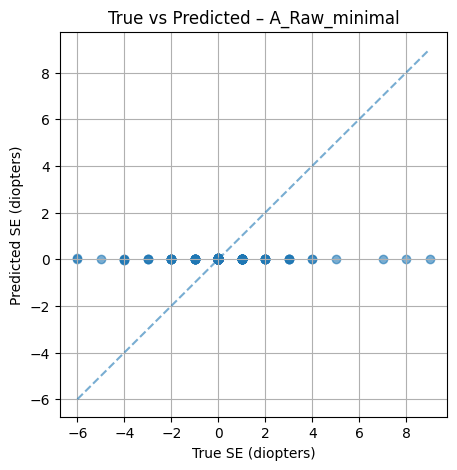

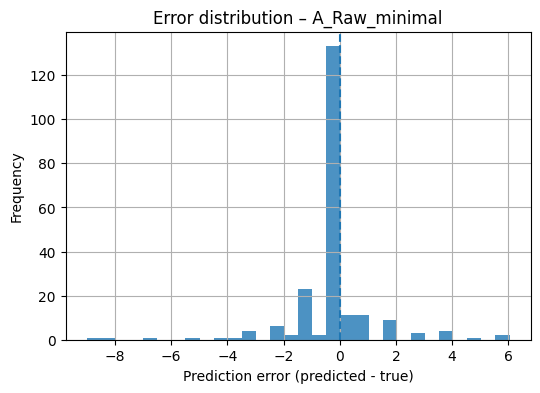

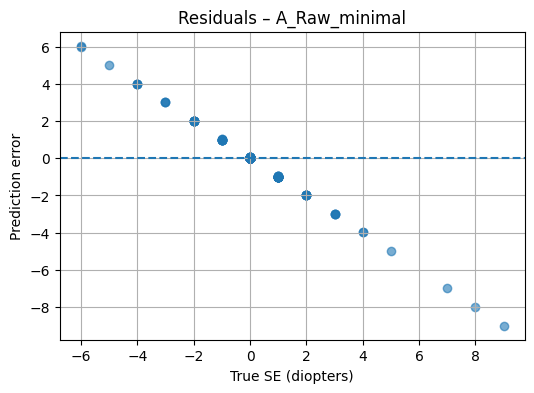

{'name': 'A_Raw_minimal', 'MAE': 0.7477519908696756, 'MSE': 2.6674557504075778, 'RMSE': 1.6332347505510583, 'R2': -0.0026007234155140946, 'mean_error': -0.08154178915485259, 'std_error': 1.6311979300590727}

===== Running B_GeoNorm =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 892ms/step - loss: 4.2200 - mae: 1.1766 - mse: 4.2200 - val_loss: 3.4535 - val_mae: 1.0051 - val_mse: 3.4535 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 952ms/step - loss: 4.9507 - mae: 1.2386 - mse: 4.9507 - val_loss: 3.4357 - val_mae: 1.0017 - val_mse: 3.4357 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 995ms/step - loss: 4.6008 - mae: 1.2339 - mse: 4.6008 - val_loss: 3.4385 - val_mae: 0.9961 - val_mse: 3.4385 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 959ms/step - loss: 4.8018 - mae: 1.2732 - mse: 4.8018 - val_loss: 3.4299 - val_mae: 1.0175 - val_mse: 3.4299 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 996ms/step - loss: 4

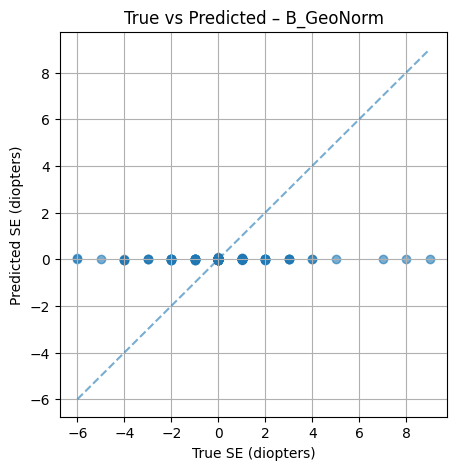

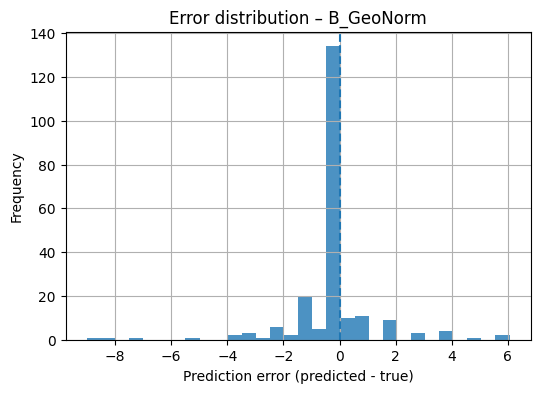

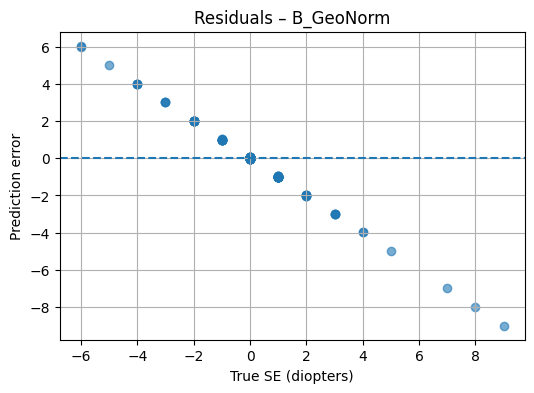

{'name': 'B_GeoNorm', 'MAE': 0.7502138687239762, 'MSE': 2.667765063873453, 'RMSE': 1.6333294413171682, 'R2': -0.002716983227734282, 'mean_error': -0.08042699915211013, 'std_error': 1.6313480810914756}

===== Running C_GeoNorm_Illum_NoAug =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 55s 933ms/step - loss: 4.2217 - mae: 1.1796 - mse: 4.2217 - val_loss: 3.4511 - val_mae: 0.9981 - val_mse: 3.4511 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 57s 955ms/step - loss: 4.9514 - mae: 1.2313 - mse: 4.9514 - val_loss: 3.4451 - val_mae: 0.9953 - val_mse: 3.4451 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 947ms/step - loss: 4.6073 - mae: 1.2304 - mse: 4.6073 - val_loss: 3.4372 - val_mae: 0.9978 - val_mse: 3.4372 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 55s 981ms/step - loss: 4.8092 - mae: 1.2721 - mse: 4.8092 - val_loss: 3.4532 - val_mae: 1.0174 - val_mse: 3.4532 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 52s 941ms/step - l

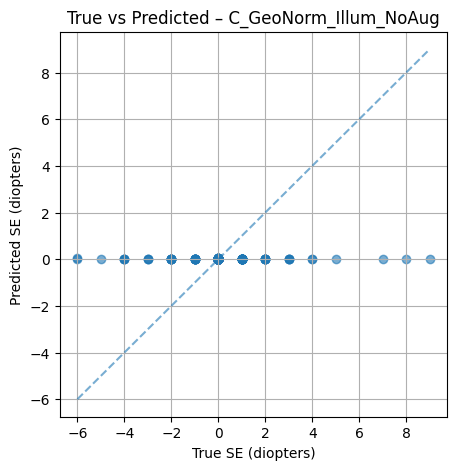

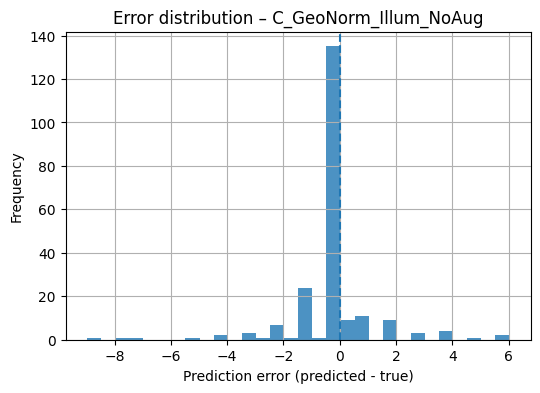

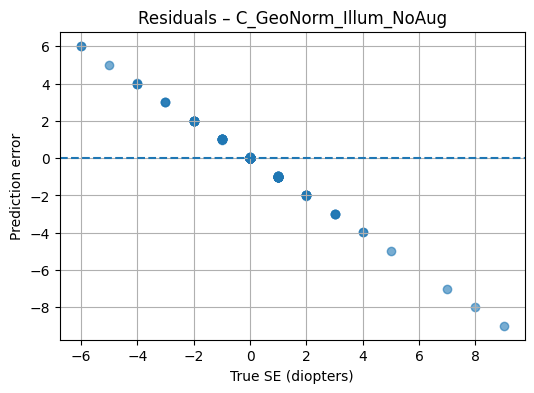

{'name': 'C_GeoNorm_Illum_NoAug', 'MAE': 0.7498825100542386, 'MSE': 2.668151004856491, 'RMSE': 1.6334475825249157, 'R2': -0.0028620445689508944, 'mean_error': -0.07578091838607384, 'std_error': 1.631688774633525}

===== Running D_GeoNorm_Aug_NoIllum =====
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - loss: 4.2170 - mae: 1.1786 - mse: 4.2170 - val_loss: 3.4561 - val_mae: 1.0164 - val_mse: 3.4561 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 4.9552 - mae: 1.2488 - mse: 4.9552 - val_loss: 3.4399 - val_mae: 0.9955 - val_mse: 3.4399 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 4.6013 - mae: 1.2271 - mse: 4.6013 - val_loss: 3.4161 - val_mae: 1.0036 - val_mse: 3.4161 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 4.7851 - mae: 1.2823 - mse: 4.7851 - val_loss: 3.4347 - val_mae: 1.0118 - val_mse: 3.4347 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss

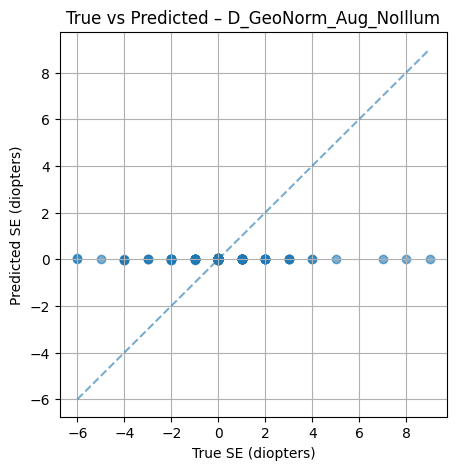

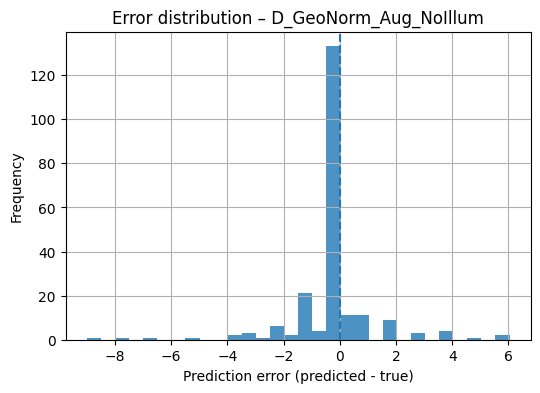

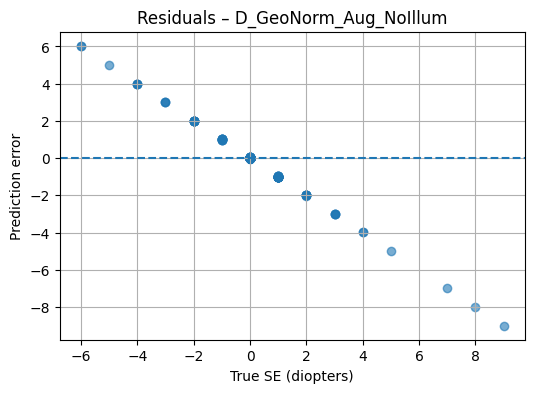

{'name': 'D_GeoNorm_Aug_NoIllum', 'MAE': 0.7489346187681921, 'MSE': 2.6645010386573187, 'RMSE': 1.632329941726647, 'R2': -0.0014901534884059764, 'mean_error': -0.07997634034058775, 'std_error': 1.6303695359160284}


,name,task,preprocessing_family,dropout,augmentation,normalization,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2,mean_error,std_error,model_path
0,A_Raw_minimal,regression,SelectivePreproc,False,False,0-1,0.995761,3.339411,0.747752,2.667456,1.633235,-0.002601,-0.081542,1.631198,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
1,B_GeoNorm,regression,SelectivePreproc,False,False,0-1,0.996058,3.366262,0.750214,2.667765,1.633329,-0.002717,-0.080427,1.631348,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
2,C_GeoNorm_Illum_NoAug,regression,SelectivePreproc,False,False,0-1,0.995326,3.398751,0.749883,2.668151,1.633448,-0.002862,-0.075781,1.631689,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...
3,D_GeoNorm_Aug_NoIllum,regression,SelectivePreproc,False,True,0-1,0.995502,3.372687,0.748935,2.664501,1.632330,-0.001490,-0.079976,1.630370,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


In [13]:
results = []
models  = {}
histories = {}
datasets = {}

for exp in EXPERIMENTS:
    mdl, hist, metrics, ds_tuple = run_experiment(exp, epochs=10)

    name = exp["name"]
    models[name] = mdl
    histories[name] = hist
    datasets[name] = ds_tuple

    model_path = MODELS_DIR_SELECTIVE / f"small_cnn_regression_without_dropout_{name}.keras"
    mdl.save(model_path)

    results.append({
        "name": name,
        "task": "regression",
        "preprocessing_family": "SelectivePreproc",
        "dropout": False,
        "augmentation": exp["do_aug"],
        "normalization": exp["normalization"],
        "best_val_mae": float(np.min(hist.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(hist.history.get("val_mse", [np.nan]))),
        "test_mae": metrics["MAE"],
        "test_mse": metrics["MSE"],
        "test_rmse": metrics["RMSE"],
        "test_r2": metrics["R2"],
        "mean_error": metrics["mean_error"],
        "std_error": metrics["std_error"],
        "model_path": str(model_path)
    })

results_df = pd.DataFrame(results)
results_df

The results table shows a comparative of the same model (small_cnn_classf) run over the 4 different sets of preprocessed pictures:
- best_val_auc: best AUC value (capacity of model to distinguish classes) obtained accross the 10 epochs on the **validation set** (1 perfect, 0.5 random)
- best_val_acc: best accuracy value (% of right guesses) obtained accross the 10 epochs on the **validation set** (watch out for unbalanced classes in dataset)
- test_auc: AUC obtained on **test set**. This might be the most important metric
- test_ap: average precision obtained on **test set** (area under precision-recall curve). Very useful with unbalanced classes since it focuses on performance on myopia class
- test_acc@0.5: accuracy obtained on **test set** when 0.5 threshold is applied (≥ 0.5 means myopia); < 0.5 means normal)

All in all:
- AUC shows how well the model distinguishes amongst classes
- Accuracy shows % of right guesses when classifying
- AP shows how well the model handles the minority class (looking at precision vs recall)


Note 1: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Note 2: handling the smaller class (AP) can be complicated since, if there is a large picture number difference amongst classes, the model might learn to state it is almost always right to predict that a picture belongs to the larger group when classifying.

The four selective preprocessing scenarios produce extremely similar regression results. Test MAE values remain between approximately **0.748 D and 0.750 D**, RMSE values remain around **1.63 D**, and all **R² values are slightly negative**.

The best test MAE is obtained by **A_Raw_minimal**, with **MAE = 0.748 D**. The best R² and RMSE are obtained by **D_GeoNorm_Aug_NoIllum**, with **R² = -0.0015** and **RMSE = 1.632 D**. However, these differences are extremely small and should not be interpreted as a meaningful advantage of one preprocessing scenario over another.

The key result is that all R² values remain approximately **0** and slightly below zero. This means that the models do not explain the variance of SE better than a simple baseline that predicts a constant value close to the mean.

Compared with the selective regression notebook **with Dropout**, removing Dropout slightly improves MAE in several scenarios, especially **B_GeoNorm** and **D_GeoNorm_Aug_NoIllum**. For example, B improves from approximately **0.777 D** to **0.750 D**, and D improves from approximately **0.776 D** to **0.749 D**. However, this is not accompanied by a meaningful improvement in R², which remains approximately zero.

-> Therefore, removing Dropout improves the absolute error slightly, but it does **not** solve the core regression problem. The model still behaves like a near-mean predictor rather than learning a useful mapping from retinal images to SE.


## 📊 4. Results

#### 📈 4.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for Keras models, making it easy to compare performance across epochs.

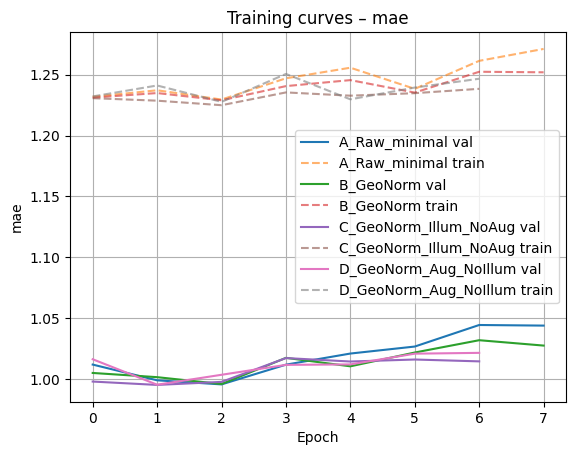

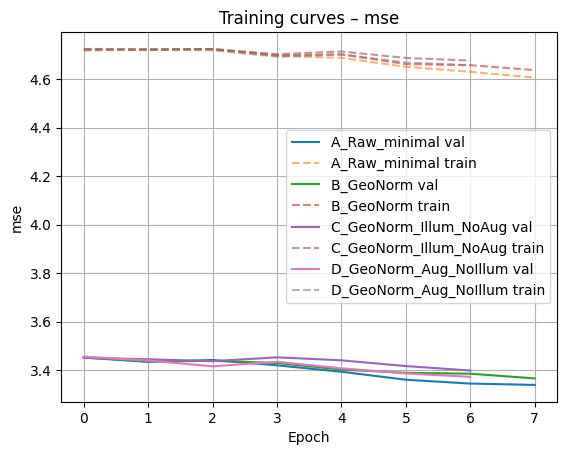

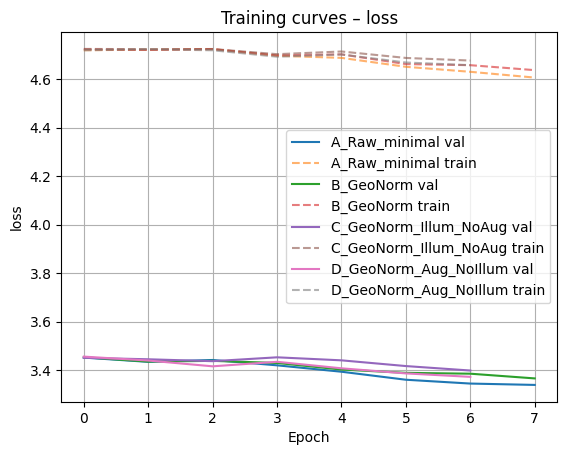

In [14]:
def plot_histories(histories, metric="mae"):
    #histories: list of keras History objects
    for name, history in histories.items():
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"{name} val")

        if metric in history.history:
            plt.plot(
                history.history[metric],
                linestyle="--",
                alpha=0.6,
                label=f"{name} train"
            )

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"Training curves – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

#Let's have them set side by side to compare
plot_histories(histories, metric="mae")
plot_histories(histories, metric="mse")
plot_histories(histories, metric="loss")

The training curves show that validation MAE remains close to **1.0 D** across scenarios, while validation MSE/loss remains around **3.3–3.4**. The curves do not show a sustained improvement across epochs, and the callbacks reduce the learning rate when validation MAE stops improving.

The curves are very similar between preprocessing scenarios, which supports the numerical results: none of the selective preprocessing variants clearly changes the model's ability to predict SE.

Compared with the selective regression notebook **with Dropout**, the no-Dropout training curves are not fundamentally different. Removing Dropout may slightly reduce the final test MAE, but the validation behaviour still suggests that the model quickly reaches a plateau and does not learn a strong image-based SE signal.


#### ⚖️ 4.2 Direct comparison A vs B vs C vs D on ROC & PR
This code evaluates multiple outcomes on the same test set, computes ROC and Precision–Recall curves (with AUC and AP), and overlays the curves to compare their performance directly.

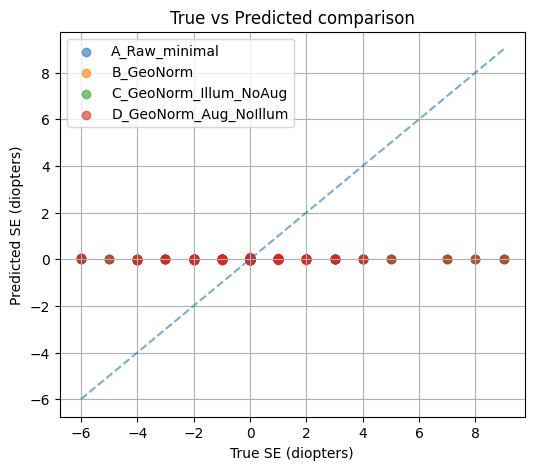

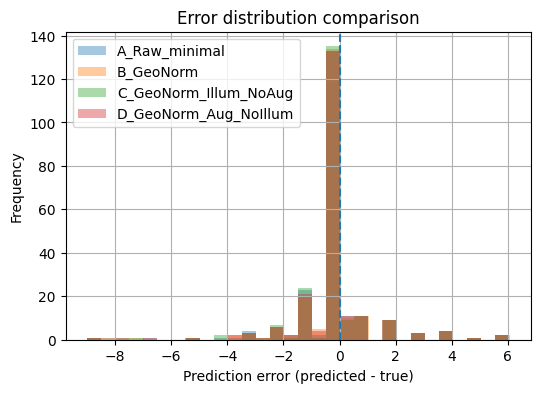

In [15]:
def compare_models_on_test(model_dict, scenario_splits, normalization="0-1"):
    comparison = {}

    for name, model in model_dict.items():
        test_csv = scenario_splits[name]["test"]

        test_ds = make_ds(test_csv, training=False, normalization=normalization, do_aug=False)
        y_true, y_pred = collect_preds(model, test_ds)
        errors = y_pred - y_true

        comparison[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "errors": errors
        }

    plt.figure(figsize=(6, 5))
    
    for name, d in comparison.items():
        plt.scatter(d["y_true"], d["y_pred"], alpha=0.6, label=name)

    all_true = np.concatenate([d["y_true"] for d in comparison.values()])
    all_pred = np.concatenate([d["y_pred"] for d in comparison.values()])

    min_val = min(all_true.min(), all_pred.min())
    max_val = max(all_true.max(), all_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)
    plt.xlabel("True SE (diopters)")
    plt.ylabel("Predicted SE (diopters)")
    plt.title("True vs Predicted comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(6, 4))

    for name, d in comparison.items():
        plt.hist(d["errors"], bins=30, alpha=0.4, label=name)

    plt.axvline(0, linestyle="--")
    plt.xlabel("Prediction error (predicted - true)")
    plt.ylabel("Frequency")
    plt.title("Error distribution comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    return comparison


regression_comparison = compare_models_on_test(
    models,
    SCENARIO_SPLITS,
    normalization="0-1"
)

The true-vs-predicted comparison shows the same behaviour already observed in previous regression notebooks: predictions are concentrated in a narrow range close to the centre of the SE distribution, instead of following the diagonal identity line. This means that the model is not correctly predicting low, high or extreme SE values. Instead, it tends to predict values close to the dataset mean for most images.

The error histograms are also very similar across the four scenarios. This confirms that the preprocessing choice does not substantially change the error structure. The residuals are mainly driven by the true SE distribution rather than by meaningful differences between preprocessing pipelines.

This result is consistent with the R² values close to zero. Even when MAE is around **0.75 D**, the model is not actually explaining SE variability from the retinal images.


The direct comparison confirms that the four selective preprocessing scenarios behave almost identically in regression when Dropout is removed.

Numerically, **A_Raw_minimal** gives the lowest MAE, while **D_GeoNorm_Aug_NoIllum** gives the best R² and RMSE. However, the differences are so small that they are not enough to support a clear preprocessing winner.

Compared with the selective regression notebook **with Dropout**, the no-Dropout version is slightly better in MAE, especially for scenarios B and D. However, the R² values remain approximately zero in both notebooks. Therefore, removing Dropout may slightly improve error magnitude, but it does not improve the model's ability to explain SE variability.

Compared with the **FullPreproc regression without Dropout** notebook, this selective no-Dropout notebook obtains lower MAE/RMSE values within the executed splits. However, this should be interpreted cautiously because all configurations still show R² ≈ 0. The lower MAE does not necessarily mean the model has learned clinically meaningful SE prediction; it may simply reflect the SE distribution of the test set and the model's tendency to predict near-average values.


#### 📝 4.3 Conclusions

The main conclusion is that removing Dropout does **not** make the regression model clinically useful. All scenarios obtain similar test errors, with MAE around **0.75 D**, RMSE around **1.63 D** and R² values slightly below zero.

The best MAE is obtained by **A_Raw_minimal** with **0.748 D**, while the best R² is obtained by **D_GeoNorm_Aug_NoIllum** with **R² = -0.0015**. However, these differences are minimal and do not represent a real improvement in SE prediction. Since all R² values remain around zero, the model is not explaining the variability of SE better than a constant or mean-based prediction.

Compared with the selective regression notebook **with Dropout**, removing Dropout slightly improves MAE in most scenarios. This suggests that Dropout may have been adding unnecessary regularization for this already difficult regression task. However, the improvement is only superficial: R² remains approximately zero, so the model still fails to learn a meaningful image-to-SE relationship.

Compared with the **selective classification notebooks**, the regression task remains clearly weaker. In classification, the models at least showed a small ability to rank myopic vs normal images, with AUC values around **0.60–0.62**. In regression, the models collapse towards predicting values close to the centre of the SE distribution, which produces moderate MAE but no explanatory power.

Compared with the **FullPreproc regression without Dropout** notebook, selective preprocessing without Dropout obtains lower MAE/RMSE in this execution. Nevertheless, the shared R² ≈ 0 behaviour shows that neither full preprocessing nor selective preprocessing solves the direct SE regression problem with this small CNN.

-> Overall, this notebook reinforces one of the main conclusions of the modelling stage: **direct SE regression from retinal images is much more difficult than binary classification in this dataset**. Removing Dropout and changing selective preprocessing levels can slightly modify MAE, but the model still behaves like a near-mean predictor and does not capture clinically meaningful SE variability.


All in all:

Removing Dropout from the selective-preprocessing regression model slightly reduced MAE in 
several scenarios, but it did not improve the model's ability to explain SE variability. All preprocessing scenarios obtained MAE values around 0.75 D and R² values close to zero or slightly negative. Therefore, the apparent improvement in absolute error should not be interpreted as successful SE prediction. The model continued to behave like a near-mean predictor, confirming that direct SE regression is not reliably solved by this small CNN architecture.

End :)